In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\Troy\Downloads\sci-ml\datasets\cumulative.csv')
df.head(10)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
5,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
6,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
7,8,10872983,K00756.03,Kepler-228 b,CONFIRMED,CANDIDATE,0.992,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
8,9,6721123,K00114.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-124.0,3.986,0.182,-0.098,1.958,0.322,-0.483,298.86435,42.151569,12.660
9,10,10910878,K00757.01,Kepler-229 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-83.0,4.485,0.083,-0.028,0.848,0.033,-0.072,286.99948,48.375790,15.841


In [15]:
df.fillna('NaN')
df.dropna(axis=1)
pd.get_dummies(df)



,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,...,kepler_name_Kepler-998 b,kepler_name_Kepler-999 b,koi_disposition_CANDIDATE,koi_disposition_CONFIRMED,koi_disposition_FALSE POSITIVE,koi_pdisposition_CANDIDATE,koi_pdisposition_FALSE POSITIVE,koi_tce_delivname_q1_q16_tce,koi_tce_delivname_q1_q17_dr24_tce,koi_tce_delivname_q1_q17_dr25_tce
0,1,10797460,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,...,False,False,False,True,False,True,False,False,False,True
1,2,10797460,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,...,False,False,False,True,False,True,False,False,False,True
2,3,10811496,0.000,0,1,0,0,19.899140,1.494000e-05,-1.494000e-05,...,False,False,False,False,True,False,True,False,False,True
3,4,10848459,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,...,False,False,False,False,True,False,True,False,False,True
4,5,10854555,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,...,False,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10031643,0.000,0,0,0,1,8.589871,1.846000e-04,-1.846000e-04,...,False,False,False,False,True,False,True,False,False,True
9560,9561,10090151,0.000,0,1,1,0,0.527699,1.160000e-07,-1.160000e-07,...,False,False,False,False,True,False,True,False,False,True
9561,9562,10128825,0.497,0,0,0,0,1.739849,1.780000e-05,-1.780000e-05,...,False,False,True,False,False,True,False,False,False,True
9562,9563,10147276,0.021,0,0,1,0,0.681402,2.434000e-06,-2.434000e-06,...,False,False,False,False,True,False,True,False,False,True


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load your dataset (replace 'your_dataset.csv' with your actual file path)
df = pd.read_csv(r'C:\Users\Troy\Downloads\sci-ml\datasets\cumulative.csv')

# 2. Define your target column and features
# We drop identifier columns like 'rowid' and 'kepid' so the model doesn't overfit on IDs
target_column = 'koi_score'
X = df.drop(columns=[target_column, 'rowid', 'kepid'])
y = df[target_column]

# 3. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,      # 20% allocated to the test partition
    random_state=42      # Ensures reproducible splits
)

# 4. Verify the split shapes
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Training features shape: (7651, 47)
Testing features shape: (1913, 47)


In [27]:
# Identify all columns containing text (strings)
text_columns = df.select_dtypes(include=['object']).columns
print("Text columns causing the error:", text_columns.tolist())

# Check for missing values across your features
missing_data = df.isnull().sum()[df.isnull().sum() > 0]
print("Columns with missing values:\n", missing_data)

# Get target variable distribution (checks for class imbalance)
print(df[target_column].value_counts())


Text columns causing the error: ['kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_tce_delivname']
Columns with missing values:
 kepler_name          7270
koi_score            1510
koi_period_err1       454
koi_period_err2       454
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff             363
koi_steff_err1        468
koi_steff_err2        483
koi_slogg             363
koi_slogg_err1        468
koi_slogg_err2        468
koi_srad        

C:\Users\Troy\AppData\Local\Temp\ipykernel_20512\3181586604.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


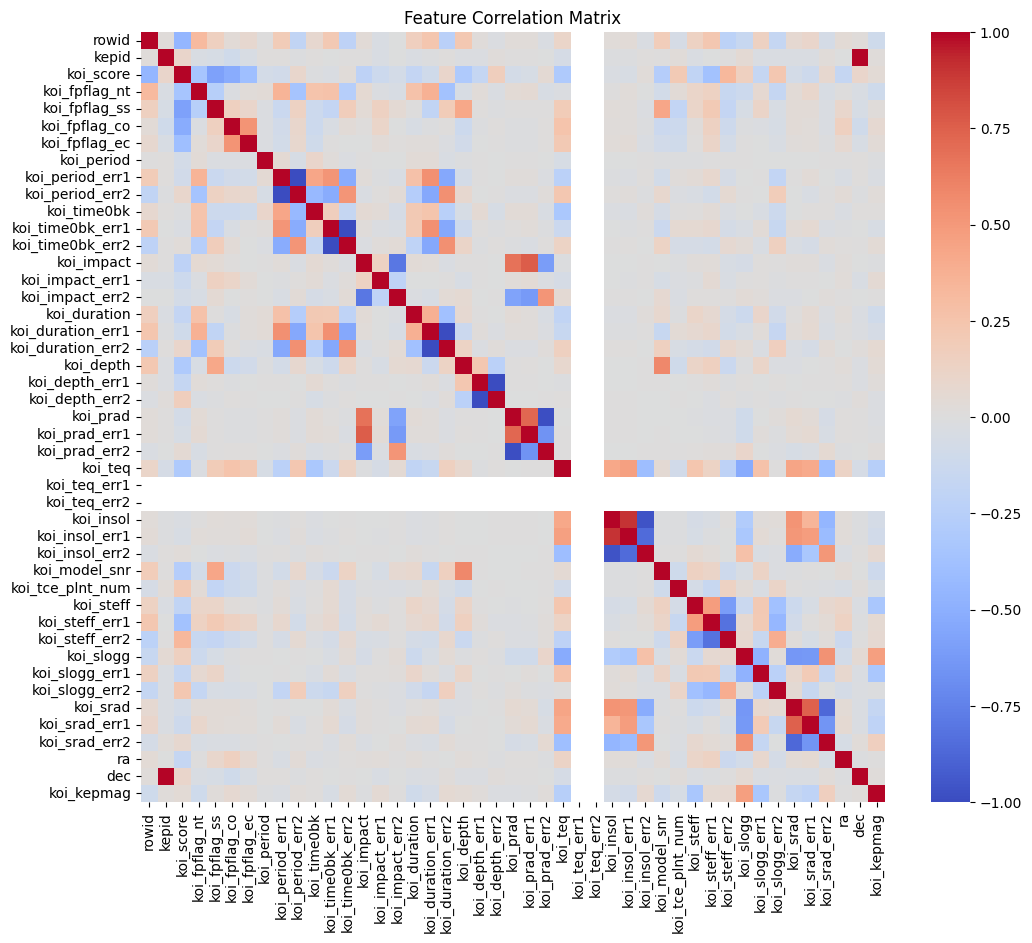

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix heatmap (only for numeric columns)
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()


In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load your dataset
df = pd.read_csv(r'C:\Users\Troy\Downloads\sci-ml\datasets\cumulative.csv')

# 2. Define target and clean up features (X)
target_column = 'koi_score'

# Drop rows where the target 'koi_score' itself is missing (NaN)
df = df.dropna(subset=[target_column])

# Drop identifier/text columns to prevent ValueErrors
# We use select_dtypes to automatically drop any remaining text/string columns
X = df.drop(columns=[target_column, 'rowid', 'kepid'])
X = X.select_dtypes(include=['number']) 

# Simple fix for any missing numeric values (fills NaNs with the column average)
X = X.fillna(X.mean())

y = df[target_column]

# 3. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 4. Initialize and train the Regression model
print("Training the RandomForestRegressor...")
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# 5. Make continuous predictions
y_pred = model.predict(X_test)

# 6. Evaluate Regression Performance
# Note: Confusion Matrix and Classification Report are strictly for classification.
# For regression, we evaluate using error distances:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Regression Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"R-squared (R²) Score:      {r2:.4f}")


Training the RandomForestRegressor...

--- Regression Evaluation Metrics ---
Mean Absolute Error (MAE): 0.0487
Mean Squared Error (MSE):  0.0122
R-squared (R²) Score:      0.9464


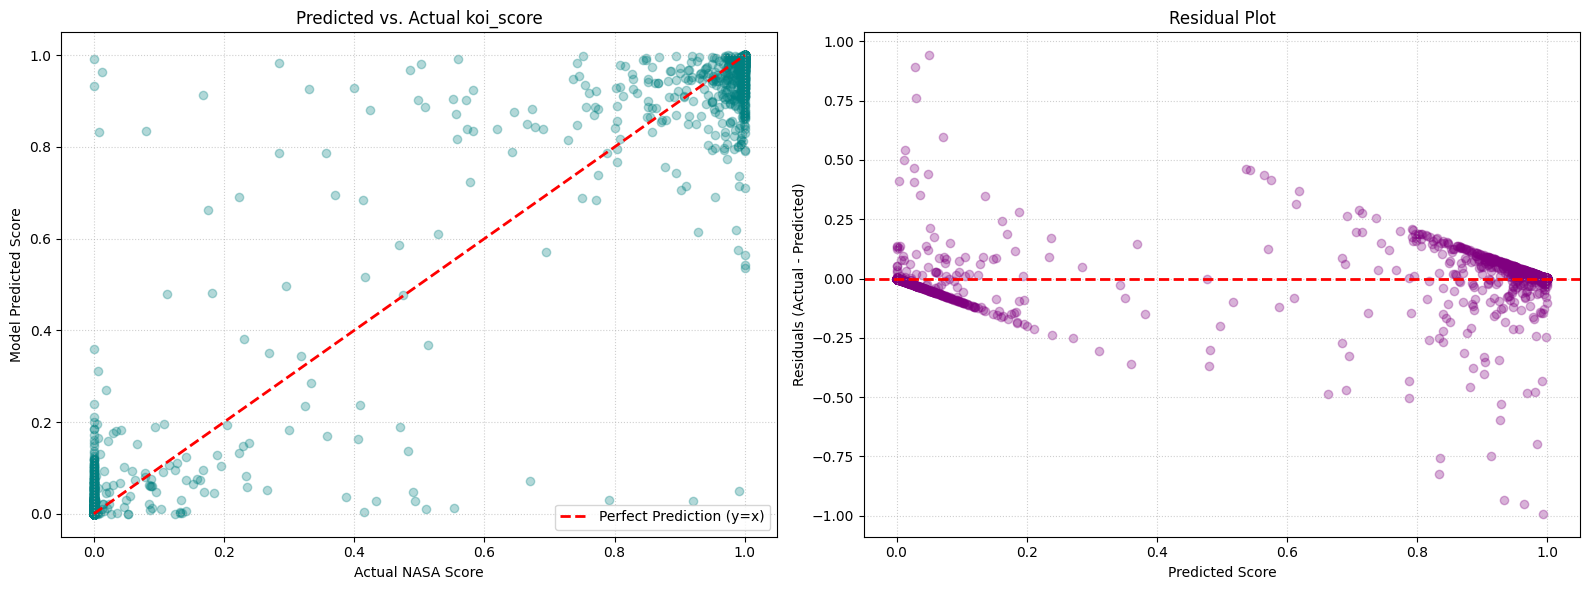

In [42]:
# Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Predicted vs. Actual Scores ---
axes[0].scatter(y_test, y_pred, alpha=0.3, color='teal')

# Add an ideal reference line (where Predicted perfectly matches Actual)
ideal_line = np.linspace(0, 1, 100)
axes[0].plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

axes[0].set_title('Predicted vs. Actual koi_score')
axes[0].set_xlabel('Actual NASA Score')
axes[0].set_ylabel('Model Predicted Score')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)


# --- PLOT 2: Residual Plot ---
# Residuals = Actual Values - Predicted Values
residuals = y_test - y_pred

axes[1].scatter(y_pred, residuals, alpha=0.3, color='purple')

# Add a horizontal zero line (where error is exactly zero)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)

axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Display the charts
plt.tight_layout()
plt.show()
